In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm
import statsmodels.stats.power as smp
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm
# reload utils
import importlib
importlib.reload(utils)
from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"
seq_length = 7 #Length of sequences
windowSizes = [1, 2, 3, 7]
fingers = ['1', '2', '3', '4', '5'] #mapping of fingers to numbers
iti = 3000   #Inter trial interval
hand = 2 #left or right hand
# total_sub_num = 10
sub_nums = [1,2,3, 4, 5, 6, 7, 8, 9, 10, 11]
num_trained_seq = 1
total_sub_num = 20
num_sessions = 3
num_blocks_per_session = 4
num_baseline_blocks = 1
num_trials_per_block = 40
# percentiles for ETs
percentile_low = 45; percentile_high = 80; percentile_low_super = 10




In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker

def set_figure_style(scale="1col"):
    """
    Set figure styling based on publication constraints.
    
    Parameters:
        scale (str): Scale of the figure, choose from "1col", "1.5col", "2col".
                     - "1col" for 8.5cm
                     - "1.5col" for 11.6cm
                     - "2col" for 17.6cm
    """
    # Define width options in cm
    widths = {"1col": 7.62, "1.5col": 11.6, "2col": 16.5}
    
    if scale not in widths:
        raise ValueError("Invalid scale. Choose from '1col', '1.5col', or '2col'.")
    
    # Convert width from cm to inches (1 cm = 0.393701 inches)
    width_in = widths[scale] * 0.393701
    
    # Set figure size (width, height)
    # Assuming height proportional to width (Golden Ratio)
    golden_ratio = (5**0.5 - 1) / 2
    rcParams["figure.figsize"] = (width_in, width_in * golden_ratio)
    
    # Set font sizes
    rcParams["font.size"] = 10  # General font size
    # rcParams["font.size"] = 20  # General font size
    rcParams["axes.titlesize"] = 12  # Figure title
    # rcParams["axes.titlesize"] = 26  # Figure title
    rcParams["axes.labelsize"] = 9  # Axis main label
    # rcParams["axes.labelsize"] = 22  # Axis main label
    rcParams["xtick.labelsize"] = 7  # Tick labels
    # rcParams["xtick.labelsize"] = 16  # Tick labels
    rcParams["ytick.labelsize"] = 7
    # rcParams["ytick.labelsize"] = 16
    rcParams["legend.fontsize"] = 8  # Legend entries
    # rcParams["legend.fontsize"] = 20  # Legend entries
    rcParams["figure.titleweight"] = "bold"
    
    # Set stroke width
    rcParams["axes.linewidth"] = 0.75
    # rcParams["axes.linewidth"] = 1.5

    # rcParams["lines.linewidth"] = 3
    
    rcParams["xtick.major.width"] = 0.75
    # rcParams["xtick.major.width"] = 1.5
    rcParams["ytick.major.width"] = 0.75
    # rcParams["ytick.major.width"] = 1.5

    
    # Subpanel lettering size
    rcParams["text.usetex"] = False  # Set to True if using LaTeX
    rcParams["axes.formatter.use_mathtext"] = True  # Math text for scientific notation

def add_subpanel_label(ax, label, fontsize=20, position=(-0.1, 1.05)):
    """
    Add a subpanel label (e.g., 'a', 'b') to a subplot.
    
    Parameters:
        ax (Axes): Matplotlib Axes object.
        label (str): The label text.
        fontsize (int): Font size for the label.
        position (tuple): Position of the label in axes coordinates.
    """
    ax.text(position[0], position[1], label, transform=ax.transAxes, 
            fontsize=fontsize, fontweight="bold", va="top", ha="left")

###
set_figure_style(scale="1col")

sns.set_palette("colorblind")


In [3]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')
subjs['zone'] = subjs['zone'].map({0:0, 1:4, 2:3, 3:2, 4:1})

# adding day column to subjs
day1_blocks =list(range(1, num_blocks_per_session + 2))  # Blocks 2 to 5
day2_blocks = list(range(num_blocks_per_session + 2, num_blocks_per_session * 2 + 2))  # Blocks 6 to 9
day3_blocks = list(range(num_blocks_per_session * 2 + 2, num_blocks_per_session * 3 + 2))  # Blocks 10 to 13
day4_blocks = list(range(num_blocks_per_session * 3 + 2, num_blocks_per_session * 4 + 2))  # Blocks 14 to 17


subjs['day'] = subjs['BN'].apply(lambda x: 1 if x in day1_blocks else (2 if x in day2_blocks else (3 if x in day3_blocks else (4 if x in day4_blocks else np.nan)))).astype(int)

In [4]:
subjs

,BN,TN,SubNum,hand,isTrain,cue,press1,press2,press3,press4,...,isCross,crossTime,globalStartTime,IPI1,IPI2,IPI3,IPI4,IPI5,IPI6,day
0,1,1,1,2,0,1243514,1,2,4,3,...,0,0,Tue Jun 03 18:11:57 2025,200,330,430,595,235,450,1
1,1,2,1,2,0,1532324,1,5,3,2,...,0,0,Tue Jun 03 18:12:04 2025,340,645,330,600,330,360,1
2,1,3,1,2,0,5142423,5,1,4,2,...,0,0,Tue Jun 03 18:12:10 2025,240,405,455,820,250,1290,1
3,1,4,1,2,0,5253431,5,2,5,3,...,0,0,Tue Jun 03 18:12:18 2025,365,495,665,395,445,310,1
4,1,5,1,2,0,4342531,4,3,4,2,...,0,0,Tue Jun 03 18:12:25 2025,260,235,655,315,1000,285,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7475,17,36,11,2,1,1243545,1,2,4,3,...,0,0,Sat Jul 19 14:28:39 2025,65,60,225,145,155,365,4
7476,17,37,11,2,1,1243545,1,2,4,3,...,0,0,Sat Jul 19 14:28:43 2025,55,60,240,135,155,410,4
7477,17,38,11,2,1,1243545,1,2,4,3,...,0,0,Sat Jul 19 14:28:48 2025,140,5,500,110,160,350,4
7478,17,39,11,2,1,1243545,1,2,4,3,...,0,0,Sat Jul 19 14:28:53 2025,50,65,255,120,160,105,4


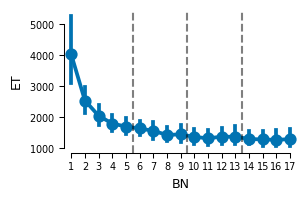

In [5]:
subjs_correct = utils.remove_error_trials(subjs) ###Removing error trials
subjs_grouped = subjs_correct.groupby(['SubNum', 'BN']).agg({
    'ET': 'median'
}).reset_index()
sns.pointplot(data = subjs_grouped, x = 'BN', y = 'ET')
for day_change in [4.5, 8.5, 12.5]:
    plt.axvline(day_change, color = 'k', linestyle = '--', alpha = 0.5)
sns.despine(trim = True)


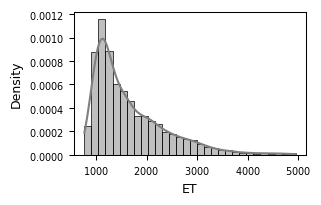

In [12]:
subjs_correct = utils.remove_error_trials(subjs) ###Removing error trials
subjs_correct = subjs_correct[subjs_correct['ET'] < 5000]
sns.histplot(subjs_correct, x='ET', bins=30, kde=True, color = 'gray', stat='density')
plt.savefig(path_figs + 'ET_Distribution.pdf', dpi=300)

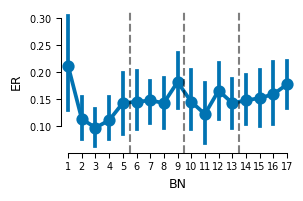

In [6]:
error_data = subjs.copy()
error_data['count'] = 1
error_data = error_data.groupby(['SubNum', 'BN']).agg({
    'count': 'sum',
    'isError': 'sum'
}).reset_index()

error_data['ER'] = error_data['isError'] / error_data['count']


sns.pointplot(data = error_data, x = 'BN', y = 'ER')
for day_change in [4.5, 8.5, 12.5]:
    plt.axvline(day_change, color = 'k', linestyle = '--', alpha = 0.5)
sns.despine(trim = True)

In [10]:
subjs.columns

Index(['BN', 'TN', 'SubNum', 'hand', 'isTrain', 'cue', 'press1', 'press2',
       'press3', 'press4', 'press5', 'press6', 'press7', 'RT', 'ET', 'MT',
       'isError', 'timingError', 'points', 'zone', 'response1', 'response2',
       'response3', 'response4', 'response5', 'response6', 'response7',
       'handPressed1', 'handPressed2', 'handPressed3', 'handPressed4',
       'handPressed5', 'handPressed6', 'handPressed7', 'pressTime1',
       'pressTime2', 'pressTime3', 'pressTime4', 'pressTime5', 'pressTime6',
       'pressTime7', 'timeThreshold', 'timeThresholdSuper',
       'estimatedPercentileHigh', 'estimatedPercentileLow',
       'estimatedPercentileLowSuper', 'startTime', 'startTimeReal', 'trialDur',
       'startTR', 'startTRtime', 'useMetronome', 'isCross', 'crossTime',
       'globalStartTime', 'IPI1', 'IPI2', 'IPI3', 'IPI4', 'IPI5', 'IPI6'],
      dtype='object')

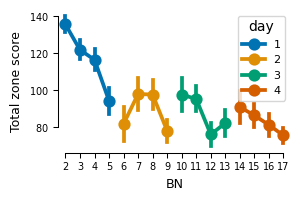

In [20]:
subjs_correct = utils.remove_error_trials(subjs) ###Removing error trials
subjs_grouped = subjs_correct.groupby(['SubNum', 'BN', 'day']).agg({
    'zone': 'sum'}).reset_index()
subjs_grouped = subjs.groupby(['SubNum', 'BN', 'day']).agg({
    'zone': 'sum'}).reset_index()
subjs_grouped = subjs_grouped[subjs_grouped['BN'] > 1]  # Exclude first block

sns.pointplot(data = subjs_grouped, x = 'BN', y = 'zone', errorbar = 'se', hue = 'day', palette = 'colorblind')
sns.despine(trim = True)
plt.ylabel('Total zone score')
plt.savefig(path_figs + 'total_zone_score_across_days.pdf', dpi=300, bbox_inches='tight')


In [24]:
print(subjs_grouped.groupby(['BN']).agg({
    'zone': 'mean'
})['zone'].values)

[135.45454545 121.72727273 116.36363636  94.18181818  81.72727273
  97.90909091  97.54545455  77.90909091  97.54545455  95.18181818
  76.          82.18181818  90.90909091  86.27272727  81.18181818
  75.45454545]


In [ ]:
fig, axs = plt.subplots(len(subjs['BN'].unique()),1, figsize=(10, 30), sharex=True)
selected_sub = subjs[subjs['SubNum'] == 6] ###Selecting one subject
day_changes = [5.5, 9.5, 13.5, 17.5] #Day change points

# selected_sub = utils.remove_error_trials(selected_sub) ###Removing error trials for the selected subject
for bn, block_data in selected_sub.groupby('BN'):
    sns.histplot(data = block_data, x = 'ET', ax = axs[bn-1], stat = 'probability')
    axs[bn-1].axvline(block_data['estimatedPercentileHigh'].values[0], linestyle = '--', color = 'black')
    axs[bn-1].axvline(block_data['estimatedPercentileLow'].values[0], linestyle = '--', color = 'black')
    axs[bn-1].axvline(block_data['estimatedPercentileLowSuper'].values[0],linestyle = '--', color = 'black')

    axs[bn-1].axvline(np.percentile(block_data['ET'], percentile_low_super), linestyle = '-', color = 'black')
    axs[bn-1].axvline(np.percentile(block_data['ET'], percentile_low), linestyle = '-', color = 'black')
    axs[bn-1].axvline(np.percentile(block_data['ET'], percentile_high), linestyle = '-', color = 'black')


    
    for day, day_change in enumerate(day_changes):
        if bn < day_change:
            break


    

    axs[bn-1].set_title(f'Block {bn} - Day {day+1}')

sns.despine(trim = True)

# Force Analysis

In [5]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

# exclude first block 
subjs = subjs[subjs['BN'] > 1]
rank_df = pd.DataFrame(index = subjs.index)
for subnum, data in subjs.groupby('SubNum'):
    data = data.sort_values(by = ['BN', 'TN'])
    data['N'] = data.groupby(['BN', 'TN']).ngroup() + 1
    rank_df.loc[data.index, 'N'] = data['N'].astype('int')
        

subjs['N'] = rank_df['N'].astype('int')
subjs = subjs[subjs['isCross'] == 0]

# adding day column to subjs
day1_blocks =list(range(2, num_blocks_per_session + 2))  # Blocks 2 to 5
day2_blocks = list(range(num_blocks_per_session + 2, num_blocks_per_session * 2 + 2))  # Blocks 6 to 9
day3_blocks = list(range(num_blocks_per_session * 2 + 2, num_blocks_per_session * 3 + 2))  # Blocks 10 to 13
day4_blocks = list(range(num_blocks_per_session * 3 + 2, num_blocks_per_session * 4 + 2))  # Blocks 14 to 17

aligned_cut_force = pd.read_csv(utils.path_misc+'aligned_cut_force.csv', sep = '\t')
aligned_cut_force = aligned_cut_force[aligned_cut_force['isCross'] == 0]


### plot original and normalized forces at different trials

In [54]:
def plot_force(data, subnum, n):
    """
    Plot the force data for a given subject and trial number.
    
    Parameters:
        subnum (int): Subject number.
        n (int): Trial number.
    """
    sub_data = data[(data['SubNum'] == subnum) & (data['N'] == n)]

    if sub_data.empty:
        print(f"No data available for SubNum {subnum} and N {n}.")
        return
    
    fig, ax = plt.subplots(figsize=(5, 2))
    
    sns.lineplot(data=sub_data, x='time', y='Force_Value', hue='Force_Number', ax=ax)
    
    ax.set_title(f'Subject {subnum}, Trial {n}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Force (N)')
    
    plt.legend(title='Finger')
    plt.show()

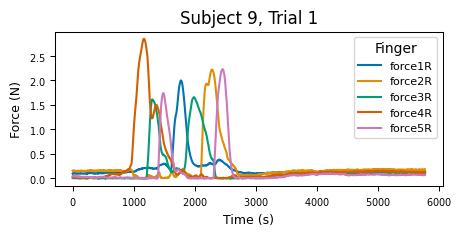

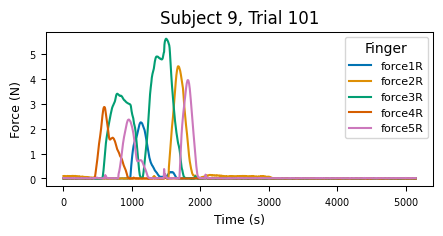

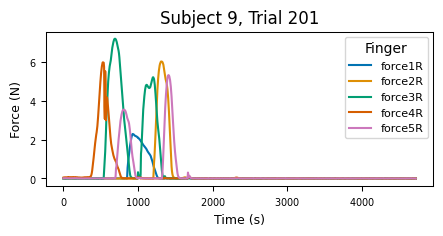

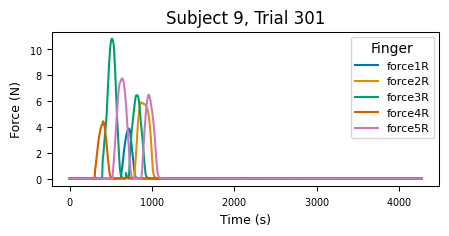

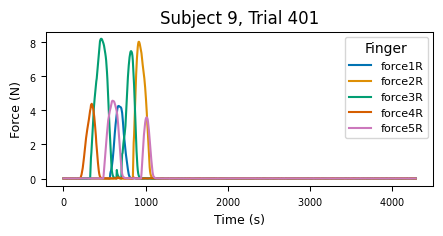

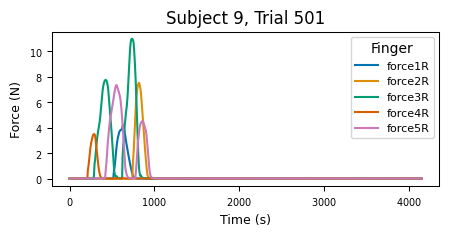

In [60]:
subjs_forces = pd.read_csv(utils.path_misc+'subjs_force_train.csv', sep = '\t')
subnum = 9
trial_gap = 100
for i in range(1, 600, trial_gap):
    plot_force(subjs_forces, subnum, i)

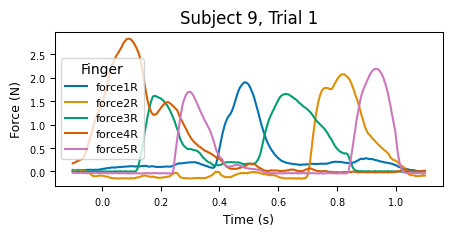

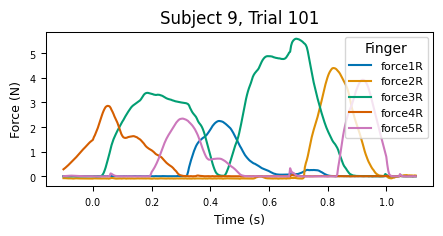

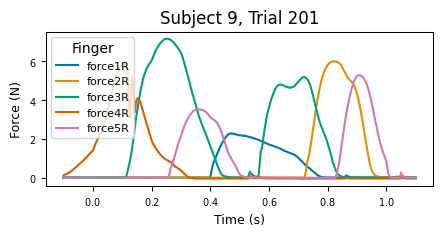

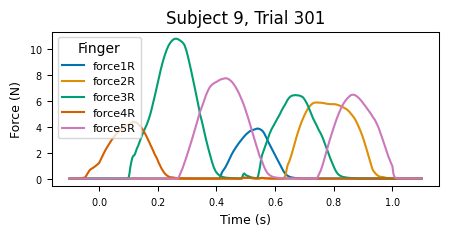

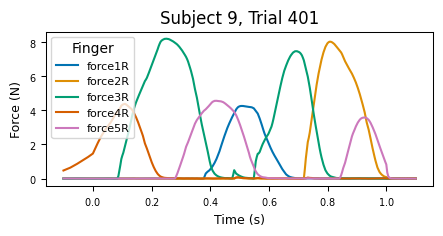

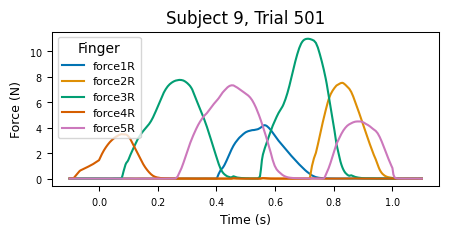

In [61]:
subnum = 9
trial_gap = 100
for i in range(1, 600, trial_gap):
    plot_force(aligned_cut_force, subnum, i)

In [6]:
forces_wide = aligned_cut_force.pivot_table(index=['SubNum', 'BN', 'TN', 'points', 'zone', 'N', 'ET'], columns=['Force_Number', 'time'], values = 'Force_Value').reset_index()
# convert MultiIndex columns to single level
forces_wide.columns = [''.join(map(str, col)).strip() for col in forces_wide.columns.values]
force_cols = [col for col in forces_wide.columns if col.startswith('force')]
new_names = {old: f'force_{i+1}' for i, old in enumerate(force_cols)}
forces_wide.rename(columns=new_names, inplace=True)


# create a force_vector column that is an np array of concatenated forces columns
forces_wide['force_vector'] = forces_wide[[col for col in forces_wide.columns if col.startswith('force_')]].apply(lambda x: np.array(x), axis=1)


forces_wide['day'] = 0
forces_wide.loc[forces_wide['BN'].isin(day1_blocks), 'day'] = 1
forces_wide.loc[forces_wide['BN'].isin(day2_blocks), 'day'] = 2
forces_wide.loc[forces_wide['BN'].isin(day3_blocks), 'day'] = 3
forces_wide.loc[forces_wide['BN'].isin(day4_blocks), 'day'] = 4


# adding day change column to the forces_wide dataframe
forces_wide['day_change'] = 0
forces_wide.loc[forces_wide['day'] != forces_wide['day'].shift(1), 'day_change'] = 1

# adding block change column to the forces_wide dataframe
forces_wide['block_change'] = 0
forces_wide.loc[forces_wide['BN'] != forces_wide['BN'].shift(1), 'block_change'] = 1


# change zone mapping from [0,1,2,3,4] to [0,4,3,2,1]
forces_wide['zone'] = forces_wide['zone'].map({0:0, 1:4, 2:3, 3:2, 4:1})

In [8]:
# # exclude first four blocks
# forces_wide = forces_wide[forces_wide['BN'] > 4]

# Modulation of Distance based on Reward

In [8]:
# calculate number of points in each zone for each subject
zone_counts = forces_wide.groupby(['SubNum', 'zone', 'points']).size().reset_index(name='count')
zone_counts

,SubNum,zone,points,count
0,1,0,-1,102
1,1,1,0,115
2,1,2,0,56
3,1,2,1,59
4,1,3,1,73
...,...,...,...,...
72,11,2,0,64
73,11,2,1,68
74,11,3,1,78
75,11,3,3,86


In [13]:
distances = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for zone, zonedata in  subdata.groupby('zone'):
        # loop through all the points in the zonedata
        for point, pointdata in zonedata.groupby('points'):
            # loop through all the points in the pointdata
            for i in range(len(pointdata)):
                row = pointdata.iloc[i]
                N = row['N']
                next_trial = subdata[subdata['N'] == N + 1]
                if not next_trial.empty and (next_trial.iloc[0]['BN'] == row['BN']):  # Ensure next trial is in the same block
                    next_row = next_trial.iloc[0]
                    # compute the euclidean distance between the force vectors of the two trials
                    force_vector_1 = row['force_vector']
                    force_vector_2 = next_row['force_vector']
                    euclidean_distance = np.linalg.norm(force_vector_1 - force_vector_2)
                    distances.append({
                        'SubNum': subind,
                        'points': point,
                        'zone': row['zone'],
                        'distance': euclidean_distance,
                        'BN': row['BN'],
                        'day': row['day'],
                        'ET': row['ET'],
                        'force': row['force_vector'],
                    })
        
distances = pd.DataFrame(distances)    
distances['count'] = 1

### distribution of distances

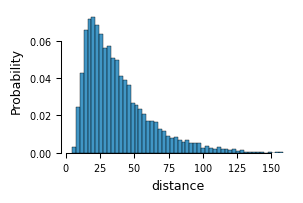

In [8]:
# sns.histplot(data=distances, x='distance', hue='zone', multiple='dodge', stat='probability')
# sns.histplot(data=distances[distances['zone'] == 3], x='distance', hue='zone', multiple='dodge', stat='probability')
sns.histplot(data=distances, x='distance', stat='probability')
sns.despine(trim=True)

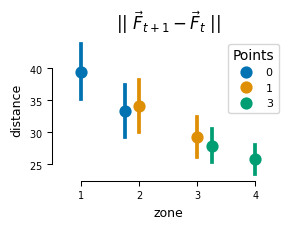

In [15]:
# exclude first three blocks
# distances = distances[distances['BN'] > 3]
distances = distances[distances['zone'] != 0]
grouped_distances = distances.groupby(['SubNum', 'points', 'zone']).agg({'distance': 'median',
                                                                         'count': 'count'}).reset_index()

non_manipulated_zones = [0,1,4]
manipulated_zones = [2,3]
non_manipulated_grouped = grouped_distances.copy()
# set rows with zones 2 and 3 to NaN
non_manipulated_grouped.loc[non_manipulated_grouped['zone'].isin(manipulated_zones), 'distance'] = np.nan
# non_manipulated_grouped = grouped_distances[grouped_distances['zone'].isin(non_manipulated_zones)]
# sns.pointplot(data = non_manipulated_grouped, x = 'zone', y = 'distance', errorbar='se', linestyles='', legend=False, color = 'gray')
sns.pointplot(data = non_manipulated_grouped, x = 'zone', y = 'distance', errorbar='se', linestyles='', legend=False, hue = 'points', palette='colorblind')


manipulated_grouped = grouped_distances[grouped_distances['zone'].isin(manipulated_zones)]
sns.pointplot(data = manipulated_grouped, x = 'zone', y = 'distance', errorbar='se', linestyles='', hue = 'points', palette = 'colorblind', dodge = 0.5)

sns.despine(trim=True)
plt.title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
plt.legend(loc = 'upper right', title = 'Points', bbox_to_anchor=(1, 1))

# for group_data in grouped_distances.groupby('zone'):
#     points = group_data[1]['points'].unique()
#     print(f"Zone: {group_data[0]}")
#     print(stats.ttest_rel(group_data[1][group_data[1]['points'] == points[0]]['distance'],
#                     group_data[1][group_data[1]['points'] == points[1]]['distance']))
    
plt.savefig(path_figs + 'trial_by_trial_distance_reward_manipulation.pdf', dpi=300, bbox_inches='tight')

Zone: 2
TtestResult(statistic=-0.8267916768792251, pvalue=0.42764251392217956, df=10)
Zone: 3
TtestResult(statistic=1.111819501957671, pvalue=0.29223048458078027, df=10)


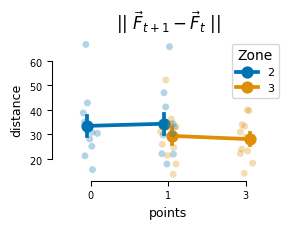

In [10]:
# exclude first three blocks
# distances = distances[distances['BN'] > 3]
grouped_distances = distances.groupby(['SubNum', 'points', 'zone']).agg({'distance': 'median',
                                                                         'count': 'count'}).reset_index()
grouped_distances = grouped_distances[grouped_distances['zone'].isin([2, 3])]

sns.stripplot(data=grouped_distances, x='points', y='distance', hue='zone', palette='colorblind', alpha = 0.3, legend=False)
sns.pointplot(data=grouped_distances, x='points', y='distance', hue='zone', palette='colorblind', dodge=0.1, errorbar='se')
sns.despine(trim=True)
plt.title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
plt.legend(loc = 'upper right', title = 'Zone', bbox_to_anchor=(1, 1))
plt.savefig(path_figs + 'trial_by_trial_distance_across_zones.pdf', dpi=300, bbox_inches='tight')

for group_data in grouped_distances.groupby('zone'):
    points = group_data[1]['points'].unique()
    print(f"Zone: {group_data[0]}")
    print(stats.ttest_rel(group_data[1][group_data[1]['points'] == points[0]]['distance'],
                    group_data[1][group_data[1]['points'] == points[1]]['distance']))
    


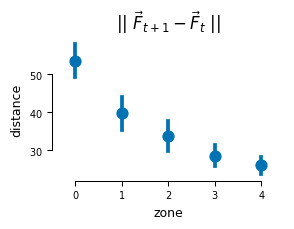

In [13]:
# exclude first three blocks
# distances = distances[distances['BN'] > 3]

# grouped_distances = distances.groupby(['SubNum', 'zone', 'day']).agg({'distance': 'median',
#                                                                          'count': 'count'}).reset_index()

grouped_distances = distances.groupby(['SubNum', 'zone']).agg({'distance': 'median',
                                                                         'count': 'count'}).reset_index()



# sns.pointplot(data=grouped_distances, x='points', y='distance', hue='day', palette='colorblind', dodge=0.4, errorbar='se')
# sns.pointplot(data=grouped_distances, x='zone', y='distance', hue='day', palette='colorblind', dodge=0.4, errorbar='se', marker = 'o', linestyles="None")
# sns.pointplot(data=grouped_distances, x='points', y='distance', errorbar='se')
sns.pointplot(data=grouped_distances, x='zone', y='distance', errorbar='se', marker = 'o', linestyles="None")


sns.despine(trim=True)
plt.title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
# plt.legend(loc = 'upper right')
plt.savefig(path_figs + 'trial_by_trial_force_distance.pdf', dpi=300, bbox_inches='tight')
# for group_data in grouped_distances.groupby('zone'):
#     points = group_data[1]['points'].unique()
#     print(f"Zone: {group_data[0]}")
#     print(stats.ttest_rel(group_data[1][group_data[1]['points'] == points[0]]['distance'],
#                     group_data[1][group_data[1]['points'] == points[1]]['distance']))



TtestResult(statistic=-2.094652032070237, pvalue=0.06263764638572848, df=10)

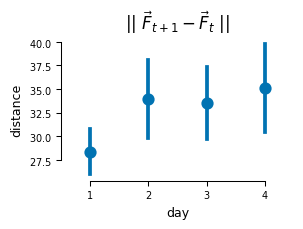

In [42]:
# distances = distances[distances['BN'] > 3]

grouped_distances = distances.groupby(['SubNum', 'day']).agg({'distance': 'median',
                                             'count': 'count'}).reset_index()
sns.pointplot(data=grouped_distances, x='day', y='distance', errorbar='se', marker = 'o', linestyles="None")
plt.title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
sns.despine(trim=True)

stats.ttest_rel(grouped_distances[grouped_distances['day'] == 1]['distance'],
               grouped_distances[grouped_distances['day'] == 4]['distance'])


In [89]:
import statsmodels.api as sm
# Perform repeated measure ANCOVA on subjects with distance as the dependent variable and zone and day as independent variables and ET as covariate
# normalize

model = sm.MixedLM.from_formula('distance ~ C(zone) + C(day) + ET',
                                data=distances, groups=distances['SubNum'])
result = model.fit()
print(result.summary())



           Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: distance   
No. Observations:   7003    Method:             REML       
No. Groups:         11      Scale:              375.4632   
Min. group size:    631     Log-Likelihood:     -30719.8284
Max. group size:    639     Converged:          Yes        
Mean group size:    636.6                                  
-----------------------------------------------------------
              Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     49.280    3.517  14.012 0.000  42.387  56.173
C(zone)[T.1] -12.030    0.868 -13.861 0.000 -13.731 -10.329
C(zone)[T.2] -17.395    0.833 -20.894 0.000 -19.027 -15.764
C(zone)[T.3] -20.845    0.820 -25.435 0.000 -22.451 -19.238
C(zone)[T.4] -22.582    0.832 -27.135 0.000 -24.213 -20.951
C(day)[T.2]    4.123    0.758   5.440 0.000   2.638   5.609
C(day)[T.3]    4.667    0.813   5.738 0.000   3.073

In [30]:
grouped_distances = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for bn, block_data in subdata.groupby('BN'):
        # remove error trials
        block_data = block_data[block_data['zone'] != 0].copy()

        block_data['speed'] = 1 / block_data['ET'] * 1000  # calculate speed as inverse of ET

        force_vectors = np.array(block_data['force_vector'].tolist())
        # calculate the mean force vector for the block
        mean_force_vector = np.mean(force_vectors, axis=0)
        # compute the variance of the force vectors in the window
        var = np.sqrt(((force_vectors - mean_force_vector) ** 2).sum(axis = 1).mean())
        grouped_distances.append({
            'SubNum': subind,
            'BN': bn,
            'variance': var,
            'zone': np.sum(block_data['zone']),
            'speed': block_data['speed'].mean(),
            'day': block_data['day'].values[0],
            'ET': block_data['ET'].median()
        })
grouped_distances = pd.DataFrame(grouped_distances)

Text(0.5, 1.0, 'Force Variability vs. Relative Speed')

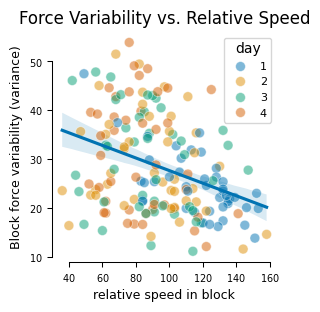

In [31]:
# Create the lmplot first (this creates its own figure)
g = sns.lmplot(data=grouped_distances, x='zone', y='variance', scatter_kws={'s': 50, 'alpha': 0.0}, ci=95, height=3, aspect=1)
# Add the colored scatter plot on top of the existing lmplot
sns.scatterplot(data=grouped_distances, x='zone', y='variance', alpha=0.5, s=50, hue='day', palette='colorblind', ax=g.ax)
sns.despine(trim=True)

plt.xlabel('relative speed in block')
plt.ylabel('Block force variability (variance)')
plt.title('Force Variability vs. Relative Speed')
# plt.savefig(path_figs + 'force_variability_vs_relative_speed.pdf', dpi=300, bbox_inches='tight')




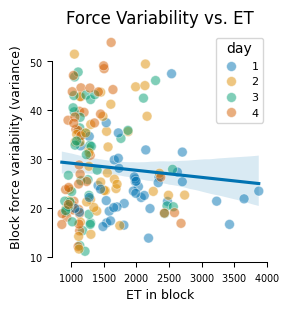

In [61]:
# Create the lmplot first (this creates its own figure)
g = sns.lmplot(data=grouped_distances, x='ET', y='variance', scatter_kws={'s': 50, 'alpha': 0.0}, ci=95, height=3, aspect=1)
# Add the colored scatter plot on top of the existing lmplot
sns.scatterplot(data=grouped_distances, x='ET', y='variance', alpha=0.5, s=50, hue='day', palette='colorblind', ax=g.ax)
sns.despine(trim=True)

plt.xlabel('ET in block')
plt.ylabel('Block force variability (variance)')
plt.title('Force Variability vs. ET')
plt.savefig(path_figs + 'force_variability_vs_ET.pdf', dpi=300, bbox_inches='tight')




In [58]:
ET_beta_per_subject = []
for subnum, subdata in grouped_distances.groupby('SubNum'):
    # fit a linear model to predict variance from ET
    X = subdata[['ET']]
    Y = subdata['variance']
    X = sm.add_constant(X)  # Add a constant term for the intercept
    model = sm.OLS(Y, X).fit()
    ET_beta_per_subject.append(model.params['ET'])
print(f"ET: {stats.ttest_1samp(ET_beta_per_subject, 0)}")

ET: TtestResult(statistic=-2.9701893097509977, pvalue=0.014041272499358593, df=10)


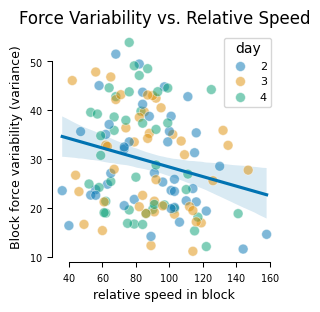

In [113]:
# Create the lmplot first (this creates its own figure)
g = sns.lmplot(data=grouped_distances[grouped_distances['day']!= 1], x='zone', y='variance', scatter_kws={'s': 50, 'alpha': 0.0}, ci=95, height=3, aspect=1)
# Add the colored scatter plot on top of the existing lmplot
sns.scatterplot(data=grouped_distances[grouped_distances['day']!= 1], x='zone', y='variance', alpha=0.5, s=50, hue='day', palette='colorblind', ax=g.ax)
sns.despine(trim=True)

plt.xlabel('relative speed in block')
plt.ylabel('Block force variability (variance)')
plt.title('Force Variability vs. Relative Speed')
plt.savefig(path_figs + 'force_variability_vs_relative_speed.pdf', dpi=300, bbox_inches='tight')




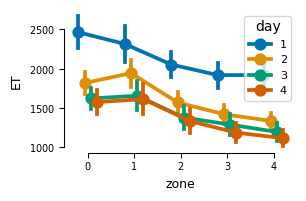

In [73]:
forces_wide_filtered = forces_wide[forces_wide['ET']< 7500]
forces_wide_grouped = forces_wide_filtered.groupby(['SubNum', 'zone', 'day']).agg({'ET': 'median'}).reset_index()
# sns.lmplot(data = forces_wide_filtered, x = 'ET', y = 'zone', scatter_kws={'s': 50, 'alpha': 0.5}, ci=95, height=3, aspect=1)
sns.pointplot(data = forces_wide_grouped, x = 'zone', y = 'ET', hue = 'day', palette = 'colorblind', dodge = 0.4, errorbar = 'se')
sns.despine(trim = True)
plt.savefig(path_figs + 'ET_vs_zone_across_days.pdf', dpi=300, bbox_inches='tight')

In [39]:
import statsmodels.api as sm

# Perform repeated measure ANCOVA on subjects with distance as the dependent variable and zone and day as independent variables and ET as covariate
# normalize

model = sm.MixedLM.from_formula('variance ~ zone + C(day) + ET',
                                data=grouped_distances, groups=grouped_distances['SubNum'])
result = model.fit()
print(result.summary())



         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: variance 
No. Observations: 176     Method:             REML     
No. Groups:       11      Scale:              33.7784  
Min. group size:  16      Log-Likelihood:     -578.9274
Max. group size:  16      Converged:          Yes      
Mean group size:  16.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    41.685    4.833  8.625 0.000 32.212 51.157
C(day)[T.2]   0.330    1.604  0.206 0.837 -2.813  3.473
C(day)[T.3]   0.125    1.771  0.071 0.944 -3.345  3.596
C(day)[T.4]   0.588    1.878  0.313 0.754 -3.092  4.268
zone         -0.093    0.019 -4.873 0.000 -0.131 -0.056
ET           -0.003    0.002 -1.860 0.063 -0.006  0.000
Group Var    62.176    5.131                           



In [109]:
import statsmodels.api as sm

# Perform repeated measure ANCOVA on subjects with distance as the dependent variable and zone and day as independent variables and ET as covariate
# normalize

model = sm.MixedLM.from_formula('variance ~ zone + C(day) + ET',
                                data=grouped_distances, groups=grouped_distances['SubNum'])
result = model.fit()
print(result.summary())



         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: variance 
No. Observations: 176     Method:             REML     
No. Groups:       11      Scale:              34.1890  
Min. group size:  16      Log-Likelihood:     -579.8474
Max. group size:  16      Converged:          Yes      
Mean group size:  16.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    39.794    4.857  8.194 0.000 30.276 49.313
C(day)[T.2]   0.817    1.610  0.508 0.612 -2.338  3.972
C(day)[T.3]   0.746    1.785  0.418 0.676 -2.753  4.245
C(day)[T.4]   1.305    1.878  0.695 0.487 -2.376  4.986
zone         -0.094    0.019 -4.846 0.000 -0.131 -0.056
ET           -0.002    0.002 -1.298 0.194 -0.005  0.001
Group Var    60.982    5.002                           



In [111]:
import statsmodels.api as sm

# Perform repeated measure ANCOVA on subjects with distance as the dependent variable and zone and day as independent variables and ET as covariate
# normalize
grouped_distances_not_day1 = grouped_distances[grouped_distances['day'] != 1]
model = sm.MixedLM.from_formula('variance ~ zone + C(day) + ET',
                                data=grouped_distances_not_day1, groups=grouped_distances_not_day1['SubNum'])
result = model.fit()
print(result.summary())



         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: variance 
No. Observations: 132     Method:             REML     
No. Groups:       11      Scale:              32.7959  
Min. group size:  12      Log-Likelihood:     -438.0494
Max. group size:  12      Converged:          Yes      
Mean group size:  12.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    43.889    7.189  6.105 0.000 29.799 57.979
C(day)[T.3]  -0.369    1.375 -0.268 0.789 -3.064  2.327
C(day)[T.4]   0.059    1.507  0.039 0.969 -2.894  3.013
zone         -0.102    0.023 -4.392 0.000 -0.147 -0.056
ET           -0.004    0.004 -1.056 0.291 -0.011  0.003
Group Var    88.543    7.584                           



In [46]:
import plotly.graph_objects as go
import statsmodels.api as sm

fig = go.Figure()

zoom_distance = 2

# fit variance by zone and speed linearly
fig.add_trace(go.Scatter3d(
    x=grouped_distances['zone'],
    y=grouped_distances['ET'],
    z=grouped_distances['variance'],
    mode='markers',
    marker=dict(
        size=5,
        # color=grouped_distances['SubNum'],  # Color by SubNum
        colorscale='Viridis',
        opacity=0.8
    ),
    name='Force Variability'
))

# fit a plane to the data
X = grouped_distances[['zone', 'ET']]
Y = grouped_distances['variance']
X = sm.add_constant(X)  # Add a constant term for the intercept
model = sm.OLS(Y, X).fit()
# Create a grid of values for zone and speed
zone_range = np.linspace(grouped_distances['zone'].min(), grouped_distances['zone'].max(), 10)
speed_range = np.linspace(grouped_distances['ET'].min(), grouped_distances['ET'].max(), 10)
zone_grid, speed_grid = np.meshgrid(zone_range, speed_range)
# Predict variance values on the grid
X_pred = sm.add_constant(pd.DataFrame({
    'zone': zone_grid.ravel(),
    'ET': speed_grid.ravel()
}))
Y_pred = model.predict(X_pred)
# Reshape predictions to match the grid shape
Y_pred_grid = Y_pred.values.reshape(zone_grid.shape)
# Add the regression plane to the plot
fig.add_trace(go.Surface(
    x=zone_grid,
    y=speed_grid,
    z=Y_pred_grid,
    colorscale='Viridis',
    opacity=0.5,
     name='Regression Plane'
))

fig.update_layout(
    scene=dict(
        xaxis_title='Zone',
        yaxis_title='ET',
        zaxis_title='Force Variability (Variance)',
        camera=dict(eye=dict(x=zoom_distance, y=zoom_distance, z=zoom_distance))
    ),
    width = 350,
    height = 350,
    margin=dict(l=0, r=0, b=0, t=0)
)




In [210]:
grouped_distances
zone_beta_per_subject = []
speed_beta_per_subject = []
for subind, subdata in grouped_distances.groupby('SubNum'):
    # fit a linear regression line for each subject
    X = subdata[['zone', 'ET']]
    Y = subdata['variance']
    X = sm.add_constant(X)  # Add a constant term for the intercept
    model = sm.OLS(Y, X).fit()
    
    zone_beta_per_subject.append(model.params['zone'])
    speed_beta_per_subject.append(model.params['ET'])

print(f"zone: {stats.ttest_1samp(zone_beta_per_subject, 0)}")
print(f"ET: {stats.ttest_1samp(speed_beta_per_subject, 0)}")    

zone: TtestResult(statistic=-4.3435488514131695, pvalue=0.0014582402620433679, df=10)
ET: TtestResult(statistic=-0.39969631066014316, pvalue=0.6977840020973425, df=10)


# Modulation of cos angel on innovation based on Reward

In [280]:
cosines = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for zone, zonedata in subdata.groupby('zone'):
        for point, pointdata in zonedata.groupby('points'):
            # loop through all the points in the pointdata
            for i in range(len(pointdata)):
                row = pointdata.iloc[i]
                N = row['N']
                next_trial = subdata[subdata['N'] == N + 1]
                prev_trial = subdata[subdata['N'] == N - 1]
                if not next_trial.empty and not prev_trial.empty:
                    next_row = next_trial.iloc[0]
                    prev_row = prev_trial.iloc[0]
                    # compute cosine similarity between difference
                    force_vector_1 = row['force_vector']
                    force_vector_2 = next_row['force_vector']
                    force_vector_3 = prev_row['force_vector']
                    cosine_similarity = np.dot(force_vector_1 - force_vector_3, force_vector_2 - force_vector_1)/ \
                    (np.linalg.norm(force_vector_1 - force_vector_3) * np.linalg.norm(force_vector_2 - force_vector_1)) 
                    cosines.append({
                        'SubNum': subind,
                        'points': point,
                        'zone': row['zone'],
                        'cosine_similarity': cosine_similarity,
                        'BN': row['BN'],
                        'day': row['day'],
                        'ET': row['ET'],
                    })


cosines = pd.DataFrame(cosines)
        
cosines['count'] = 1

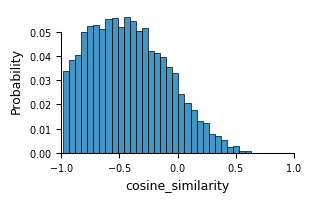

In [281]:
# sns.histplot(data=cosines, x='cosine_similarity', hue='zone', multiple='dodge', stat='probability')
sns.histplot(data=cosines, x='cosine_similarity', multiple='dodge', stat='probability')
plt.xlim(-1, 1)
sns.despine(trim=True)

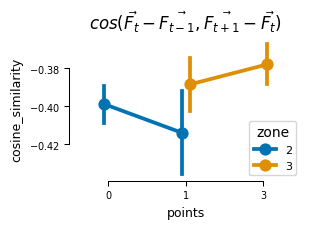

Zone: 2
TtestResult(statistic=0.765224197712096, pvalue=0.46181588076557034, df=10)
Zone: 3
TtestResult(statistic=-0.7022120072524237, pvalue=0.4985654556429234, df=10)


In [282]:
# exclude first three blocks
# cosines = cosines[cosines['BN'] > 3]
grouped_cosines = cosines.groupby(['SubNum', 'points', 'zone']).agg({'cosine_similarity': 'mean',
                                                                         'count': 'count'}).reset_index()
grouped_cosines =  grouped_cosines[grouped_cosines['zone'].isin([2, 3])]

sns.pointplot(data=grouped_cosines, x='points', y='cosine_similarity', hue='zone', palette='colorblind', dodge=0.1, errorbar='se')
sns.despine(trim=True)
plt.title(r'$cos (\vec{F_t} - \vec{F_{t-1}}, \vec{F_{t+1}} - \vec{F_t})$')
plt.show()

for group_data in grouped_cosines.groupby('zone'):
    points = group_data[1]['points'].unique()
    print(f"Zone: {group_data[0]}")
    print(stats.ttest_rel(group_data[1][group_data[1]['points'] == points[0]]['cosine_similarity'],
                    group_data[1][group_data[1]['points'] == points[1]]['cosine_similarity']))



![image.png](attachment:image.png)

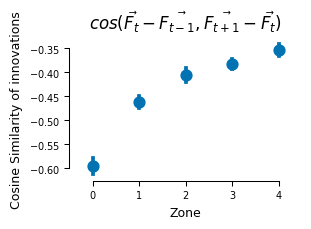

In [283]:
grouped_cosines = cosines.groupby(['SubNum','zone']).agg({'cosine_similarity': 'mean',
                                                                         'count': 'count'}).reset_index()
# grouped_cosines =  grouped_cosines[grouped_cosines['zone'].isin([1, 4])]
sns.pointplot(data=grouped_cosines, x='zone', y='cosine_similarity', errorbar='se', marker = 'o', linestyles="None")

sns.despine(trim=True)
plt.title(r'$cos (\vec{F_t} - \vec{F_{t-1}}, \vec{F_{t+1}} - \vec{F_t})$')
plt.xlabel('Zone')
plt.ylabel('Cosine Similarity of innovations')
plt.show()



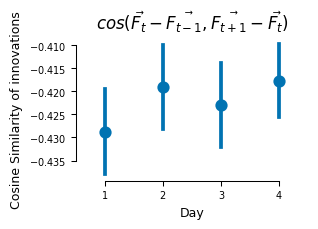

In [284]:
grouped_cosines = cosines.groupby(['SubNum','day']).agg({'cosine_similarity': 'mean',
                                                                         'count': 'count'}).reset_index()
# grouped_cosines =  grouped_cosines[grouped_cosines['zone'].isin([1, 4])]
sns.pointplot(data=grouped_cosines, x='day', y='cosine_similarity', errorbar='se', marker = 'o', linestyles="None")

sns.despine(trim=True)
plt.title(r'$cos (\vec{F_t} - \vec{F_{t-1}}, \vec{F_{t+1}} - \vec{F_t})$')
plt.xlabel('Day')
plt.ylabel('Cosine Similarity of innovations')
plt.show()



In [300]:
block_data['force_vector'].iloc[0] - block_data['force_vector'].iloc[1]

array([-0.26118294, -0.28521639, -0.31163445, ..., -0.05928428,
       -0.06481271, -0.06248495])

In [306]:
innovations.shape

(39, 1800)

In [307]:
grouped_cosines = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for bn, block_data in subdata.groupby('BN'):
        # calculate innovations vectors (next_trial - current_trial) in the block
        block_data = block_data.copy()
        block_data['innovation'] = block_data['force_vector'].diff().shift(-1)
        block_data = block_data.dropna(subset=['innovation'])

        # calculate cosine similarity between all pairs of innovation vectors in the block
        innovations = np.array(block_data['innovation'].tolist())
        cosines = []
        for i in range(len(innovations)):
            for j in range(i + 1, len(innovations)):
                cosine_similarity = np.dot(innovations[i], innovations[j]) / (np.linalg.norm(innovations[i]) * np.linalg.norm(innovations[j]))
                cosines.append(cosine_similarity)
        if len(cosines) > 0:
            mean_cosine = np.mean(cosines)
            grouped_cosines.append({
                'SubNum': subind,
                'BN': bn,
                'mean_cosine': mean_cosine,
                'zone': np.sum(block_data['zone']),
                'day': block_data['day'].values[0],
                'ET': block_data['ET'].mean()
            })
grouped_cosines = pd.DataFrame(grouped_cosines)

Text(7.424072265625009, 0.5, 'Mean Cosine Similarity of innovations')

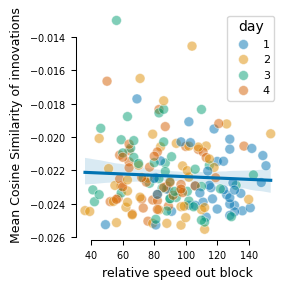

In [312]:
sns.lmplot(data=grouped_cosines, x='zone', y='mean_cosine', scatter_kws={'s': 50, 'alpha': 0.0}, ci=95, height=3, aspect=1)
sns.scatterplot(data=grouped_cosines, x='zone', y='mean_cosine', alpha=0.5, s=50, hue='day', palette='colorblind')

sns.despine(trim=True)
plt.xlabel('relative speed out block')
plt.ylabel('Mean Cosine Similarity of innovations')


In [335]:
model = sm.MixedLM.from_formula('mean_cosine ~ zone + C(day) + ET',
                                data=grouped_cosines, groups=grouped_cosines['SubNum'])
result = model.fit()
print(result.summary())

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_cosine
No. Observations: 176     Method:             REML       
No. Groups:       11      Scale:              0.0000     
Min. group size:  16      Log-Likelihood:     790.3770   
Max. group size:  16      Converged:          Yes        
Mean group size:  16.0                                   
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept     -0.021    0.001 -17.228 0.000 -0.023 -0.019
C(day)[T.2]   -0.000    0.001  -0.191 0.848 -0.001  0.001
C(day)[T.3]    0.000    0.001   0.266 0.790 -0.001  0.001
C(day)[T.4]   -0.000    0.001  -0.097 0.923 -0.001  0.001
zone          -0.000    0.000  -0.178 0.859 -0.000  0.000
ET            -0.000    0.000  -1.853 0.064 -0.000  0.000
Group Var      0.000    0.000                            



/Users/amin/Library/Python/3.9/lib/python/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



# Modulation of cos angel based on Reward

In [272]:
cosines = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for zone, zonedata in subdata.groupby('zone'):
        for point, pointdata in zonedata.groupby('points'):
            for i in range(len(pointdata)):
                row = pointdata.iloc[i]
                N = row['N']
                next_trial = subdata[subdata['N'] == N + 1]
                if not next_trial.empty:
                    next_row = next_trial.iloc[0]
                    # compute cosine similarity 
                    force_vector_1 = row['force_vector']
                    force_vector_2 = next_row['force_vector']
                    cosine_similarity = np.dot(force_vector_1, force_vector_2) / \
                    (np.linalg.norm(force_vector_1) * np.linalg.norm(force_vector_2))
                    # append to the cosines list
                    cosines.append({
                        'SubNum': subind,
                        'points': point,
                        'zone': row['zone'],
                        'cosine_similarity': cosine_similarity,
                        'BN': row['BN'],
                        'day': row['day']
                    })



cosines = pd.DataFrame(cosines)
        
cosines['count'] = 1

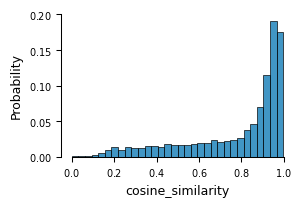

In [273]:
sns.histplot(data=cosines, x='cosine_similarity', stat='probability')
sns.despine(trim=True)

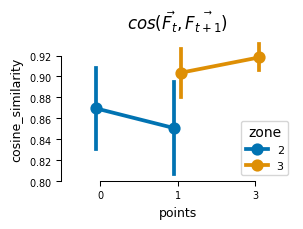

Zone: 2
TtestResult(statistic=1.8857363324786849, pvalue=0.08868247777420922, df=10)
Zone: 3
TtestResult(statistic=-1.221862660328202, pvalue=0.24978008225979217, df=10)


In [274]:
# exclude first three blocks
# cosines = cosines[cosines['BN'] > 3]
grouped_cosines = cosines.groupby(['SubNum', 'points', 'zone']).agg({'cosine_similarity': 'median',
                                                                         'count': 'count'}).reset_index()
grouped_cosines = grouped_cosines[grouped_cosines['zone'].isin([2, 3])]

sns.pointplot(data=grouped_cosines, x='points', y='cosine_similarity', hue='zone', palette='colorblind', dodge=0.1, errorbar='se')
sns.despine(trim=True)
plt.title(r'$cos (\vec{F_t}, \vec{F_{t+1}})$')
plt.show()

for group_data in grouped_cosines.groupby('zone'):
    points = group_data[1]['points'].unique()
    print(f"Zone: {group_data[0]}")
    print(stats.ttest_rel(group_data[1][group_data[1]['points'] == points[0]]['cosine_similarity'],
                    group_data[1][group_data[1]['points'] == points[1]]['cosine_similarity']))
    



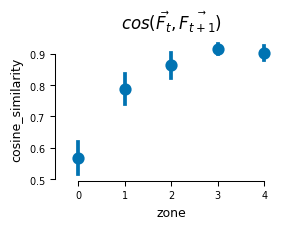

In [275]:
# exclude first three blocks
# cosines = cosines[cosines['BN'] > 3]
grouped_cosines = cosines.groupby(['SubNum', 'zone']).agg({'cosine_similarity': 'median',
                                                                         'count': 'count'}).reset_index()
# grouped_cosines = grouped_cosines[grouped_cosines['zone'].isin([2, 3])]

sns.pointplot(data=grouped_cosines, x='zone', y='cosine_similarity', errorbar='se', marker = 'o', linestyles="None")
sns.despine(trim=True)
plt.title(r'$cos (\vec{F_t}, \vec{F_{t+1}})$')
plt.show()
    



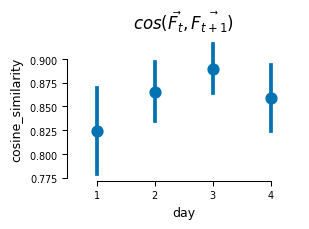

TtestResult(statistic=-1.8501599560013697, pvalue=0.09402045841360882, df=10)

In [279]:
# exclude first three blocks
# cosines = cosines[cosines['BN'] > 3]
grouped_cosines = cosines.groupby(['SubNum', 'day']).agg({'cosine_similarity': 'median',
                                                                         'count': 'count'}).reset_index()
# grouped_cosines = grouped_cosines[grouped_cosines['zone'].isin([2, 3])]

sns.pointplot(data=grouped_cosines, x='day', y='cosine_similarity', errorbar='se', marker = 'o', linestyles="None")
sns.despine(trim=True)
plt.title(r'$cos (\vec{F_t}, \vec{F_{t+1}})$')
plt.show()
    
stats.ttest_rel(grouped_cosines[grouped_cosines['day'] == 1]['cosine_similarity'],
                grouped_cosines[grouped_cosines['day'] == 2]['cosine_similarity'])



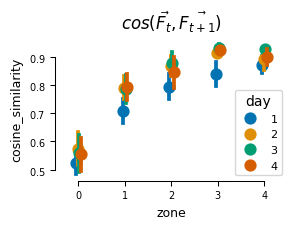

In [243]:
# exclude first three blocks
# cosines = cosines[cosines['BN'] > 3]
grouped_cosines = cosines.groupby(['SubNum', 'zone', 'day']).agg({'cosine_similarity': 'median',
                                                                         'count': 'count'}).reset_index()
# grouped_cosines = grouped_cosines[grouped_cosines['zone'].isin([2, 3])]

sns.pointplot(data=grouped_cosines, x='zone', y='cosine_similarity', hue='day', palette='colorblind', dodge=0.1, errorbar='se', marker = 'o', linestyles="None")
sns.despine(trim=True)
plt.title(r'$cos (\vec{F_t}, \vec{F_{t+1}})$')
plt.show()
    



In [251]:
AnovaRM(data = grouped_cosines, depvar = 'cosine_similarity', subject = 'SubNum', within = ['zone', 'day']).fit().anova_table

,F Value,Num DF,Den DF,Pr > F
zone,33.849927,4.0,40.0,2.379565e-12
day,4.786875,3.0,30.0,7.658054e-03
zone:day,0.399894,12.0,120.0,9.612723e-01


# Modulation of speed based on reward

In [16]:
next_ETs = []
# forces_wide_correct = forces_wide[forces_wide['zone'] != 0]
forces_wide_correct = forces_wide
for subind, subdata in forces_wide_correct.groupby('SubNum'):
    for zone, zonedata in subdata.groupby('zone'):
        for point, pointdata in zonedata.groupby('points'):
            # loop through all the points in pointdata
            for i in range(len(pointdata)):
                row = pointdata.iloc[i]
                N = row['N']
                next_trial = subdata[subdata['N'] == N + 1]
                if not next_trial.empty and (next_trial.iloc[0]['BN'] == row['BN']):  # Ensure next trial is in the same block
                    next_row = next_trial.iloc[0]
                    # append to the next_ETs list
                    next_ETs.append({
                        'SubNum': subind,
                        'points': point,
                        'zone': row['zone'],
                        'ET':  next_row['ET'],
                        'BN': row['BN']
                    })


        

next_ETs = pd.DataFrame(next_ETs)
        
next_ETs['count'] = 1

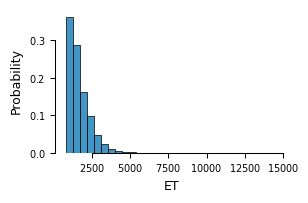

In [17]:
sns.histplot(data = next_ETs, x='ET', stat='probability', bins=30)
sns.despine(trim=True)

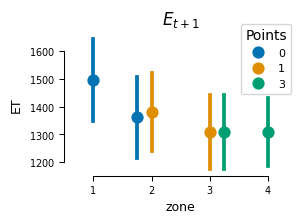

In [37]:
next_ETs = next_ETs[next_ETs['BN'] > 5]  # Exclude first day blocks
next_ETs = next_ETs[next_ETs['zone'] != 0]

grouped_speeds = next_ETs.groupby(['SubNum', 'zone', 'points']).agg({'ET': 'median'}).reset_index()

non_manipulated_zones = [0,1,4]
manipulated_zones = [2,3]
non_manipulated_grouped = grouped_speeds.copy()
# set rows with zones 2 and 3 to NaN
non_manipulated_grouped.loc[non_manipulated_grouped['zone'].isin(manipulated_zones), 'ET'] = np.nan
# non_manipulated_grouped = grouped_speeds[grouped_speeds['zone'].isin(non_manipulated_zones)]
sns.pointplot(data = non_manipulated_grouped, x = 'zone', y = 'ET', errorbar='se', linestyles='', legend=False, hue = 'points', palette='colorblind')

manipulated_grouped = grouped_speeds[grouped_speeds['zone'].isin(manipulated_zones)]
sns.pointplot(data = manipulated_grouped, x = 'zone', y = 'ET', errorbar='se', linestyles='', hue = 'points', palette = 'colorblind', dodge = 0.5)

plt.title(r'$E_{t+1}$')
plt.legend(loc='upper right', title = 'Points', bbox_to_anchor=(1, 1.1))

sns.despine(trim=True)

# for grouped_data in grouped_speeds.groupby('zone'):
#     points = grouped_data[1]['points'].unique()
#     print(f"Zone: {grouped_data[0]}")
#     print(stats.ttest_rel(grouped_data[1][grouped_data[1]['points'] == points[0]]['ET'],
#                     grouped_data[1][grouped_data[1]['points'] == points[1]]['ET']))

plt.savefig(path_figs + 'next_trial_ET_vs_zone.pdf', dpi=300, bbox_inches='tight')


Zone: 2
TtestResult(statistic=-1.6694382532163359, pvalue=0.12598826532398807, df=10)
Zone: 3
TtestResult(statistic=-0.08512071868448007, pvalue=0.9338454982057653, df=10)


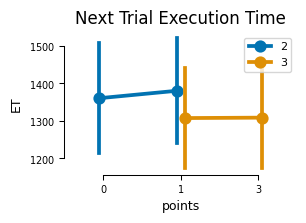

In [71]:
# next_ETs = next_ETs[next_ETs['BN'] > 5]  # Exclude first day block
grouped_speeds = next_ETs.groupby(['SubNum', 'zone', 'points']).agg({'ET': 'median'}).reset_index()

grouped_speeds = grouped_speeds[grouped_speeds['zone'].isin([2, 3])]
sns.pointplot(data=grouped_speeds, x='points', y='ET', hue='zone', palette='colorblind', dodge=0.1, errorbar='se')
plt.title('Next Trial Execution Time')
plt.legend(loc='upper right')

sns.despine(trim=True)

for grouped_data in grouped_speeds.groupby('zone'):
    points = grouped_data[1]['points'].unique()
    print(f"Zone: {grouped_data[0]}")
    print(stats.ttest_rel(grouped_data[1][grouped_data[1]['points'] == points[0]]['ET'],
                    grouped_data[1][grouped_data[1]['points'] == points[1]]['ET']))


In [36]:
grouped_speeds

,SubNum,zone,points,ET
2,1,2,0,1195.0
3,1,2,1,1225.0
4,1,3,1,1230.0
5,1,3,3,1300.0
9,2,2,0,1070.0
10,2,2,1,1070.0
11,2,3,1,1045.0
12,2,3,3,1095.0
16,3,2,0,1365.0
17,3,2,1,1455.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


TtestResult(statistic=3.156127087105618, pvalue=0.010225894719653073, df=10)


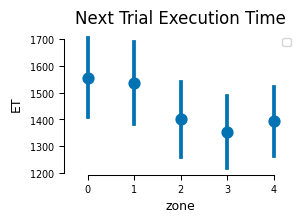

In [51]:
# next_ETs = next_ETs[next_ETs['BN'] > 3]  # Exclude first three block
grouped_speeds = next_ETs.groupby(['SubNum', 'zone']).agg({'ET': 'median'}).reset_index()

# grouped_speeds = grouped_speeds[grouped_speeds['zone'].isin([2, 3])]
# sns.pointplot(data=grouped_speeds, x='zone', y='ET', dodge=0.1, errorbar='se')
sns.pointplot(data=grouped_speeds, x='zone', y='ET', errorbar='se', marker = 'o', linestyles="None")
plt.title('Next Trial Execution Time')
plt.legend(loc='upper right')

sns.despine(trim=True)

print(stats.ttest_rel(grouped_speeds[grouped_speeds['zone'] == 2]['ET'],
                grouped_speeds[grouped_speeds['zone'] == 3]['ET']))


In [346]:
subjs

,BN,TN,SubNum,hand,isTrain,cue,press1,press2,press3,press4,...,isCross,crossTime,globalStartTime,IPI1,IPI2,IPI3,IPI4,IPI5,IPI6,N
40,2,1,1,2,1,1214532,1,2,1,4,...,0,0,Tue Jun 03 18:18:57 2025,120,250,460,365,505,330,1
41,2,2,1,2,1,1214532,1,2,1,4,...,0,0,Tue Jun 03 18:19:03 2025,135,200,420,320,630,305,2
42,2,3,1,2,1,1214532,1,2,1,4,...,0,0,Tue Jun 03 18:19:09 2025,130,195,430,355,415,325,3
43,2,4,1,2,1,1214532,1,2,1,4,...,0,0,Tue Jun 03 18:19:15 2025,130,270,450,250,495,255,4
44,2,5,1,2,1,1214532,1,2,1,4,...,0,0,Tue Jun 03 18:19:20 2025,115,205,765,285,515,290,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7475,17,36,11,2,1,1243545,1,2,4,3,...,0,0,Sat Jul 19 14:28:39 2025,65,60,225,145,155,365,636
7476,17,37,11,2,1,1243545,1,2,4,3,...,0,0,Sat Jul 19 14:28:43 2025,55,60,240,135,155,410,637
7477,17,38,11,2,1,1243545,1,2,4,3,...,0,0,Sat Jul 19 14:28:48 2025,140,5,500,110,160,350,638
7478,17,39,11,2,1,1243545,1,2,4,3,...,0,0,Sat Jul 19 14:28:53 2025,50,65,255,120,160,105,639


In [337]:
grouped_ETs = subjs.groupby(['SubNum', 'BN']).agg({'ET': 'median'}).reset_index()


Subject 1: a=1300.27, b=0.4460, c=1198.90
Subject 2: a=724.04, b=0.5812, c=1077.11
Subject 3: a=2271.26, b=0.3785, c=1256.82
Subject 4: a=1312.04, b=0.1745, c=1113.83
Subject 5: a=1204.98, b=0.2718, c=1130.39
Subject 6: a=2259.25, b=0.7283, c=1983.13
Subject 7: a=793.50, b=0.8628, c=1000.58
Subject 8: a=1336.13, b=0.2305, c=888.31
Subject 9: a=1331.96, b=0.1908, c=952.17
Subject 10: a=902.18, b=0.6573, c=2540.43
Subject 11: a=571.00, b=0.4237, c=1385.13


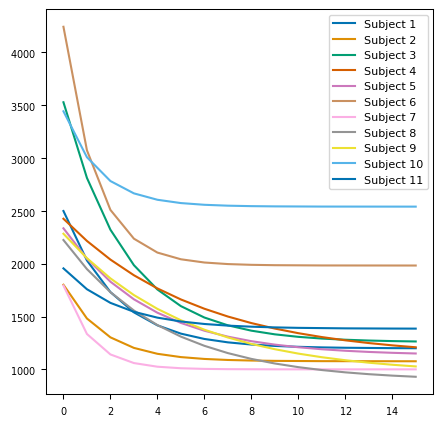

In [390]:
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c


parameters_df = []

pianist_subjs = [2,5,7,8,9,11]

from scipy.optimize import curve_fit
fig = plt.figure(figsize=(5, 5))
for subind, subdata in subjs.groupby('SubNum'):
    subdata = utils.remove_error_trials(subdata)
    xdata = subdata['BN'] - 2
    ydata = subdata['ET']
    popt, pcov = curve_fit(exp_func, xdata, ydata, bounds=(0, [5000., 1., 5000.]))
    print(f"Subject {subind}: a={popt[0]:.2f}, b={popt[1]:.4f}, c={popt[2]:.2f}")
    plt.plot(xdata, exp_func(xdata, *popt), label=f'Subject {subind}')
    parameters_df.append({
        'SubNum': subind,
        'a': popt[0],
        'b': popt[1],
        'c': popt[2],
        'is_pianist': subind in pianist_subjs
    })
plt.legend()

parameters_df = pd.DataFrame(parameters_df)




<Axes: xlabel='is_pianist', ylabel='b'>

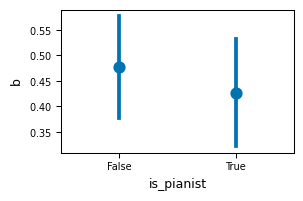

In [393]:
sns.pointplot(parameters_df, x = 'is_pianist', y = 'b', errorbar='se', marker = 'o', linestyles="None")

<Axes: xlabel='is_pianist', ylabel='init_point'>

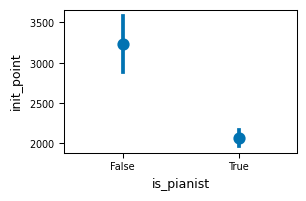

In [398]:
sns.pointplot(parameters_df, x = 'is_pianist', y = 'init_point', errorbar='se', marker = 'o', linestyles="None")

<Axes: xlabel='is_pianist', ylabel='c'>

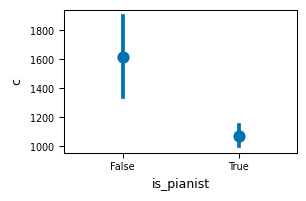

In [399]:
sns.pointplot(parameters_df, x = 'is_pianist', y = 'c', errorbar='se', marker = 'o', linestyles="None")

In [395]:
parameters_df['init_point'] = parameters_df['a'] + parameters_df['c']

In [394]:
stats.ttest_ind(parameters_df[parameters_df['is_pianist'] == True]['b'],
               parameters_df[parameters_df['is_pianist'] == False]['b'])

TtestResult(statistic=-0.34100344018879264, pvalue=0.7409265836392566, df=9.0)

In [396]:
stats.ttest_ind(parameters_df[parameters_df['is_pianist'] == True]['init_point'],
               parameters_df[parameters_df['is_pianist'] == False]['init_point'])

TtestResult(statistic=-3.541611902060325, pvalue=0.006298164661084124, df=9.0)

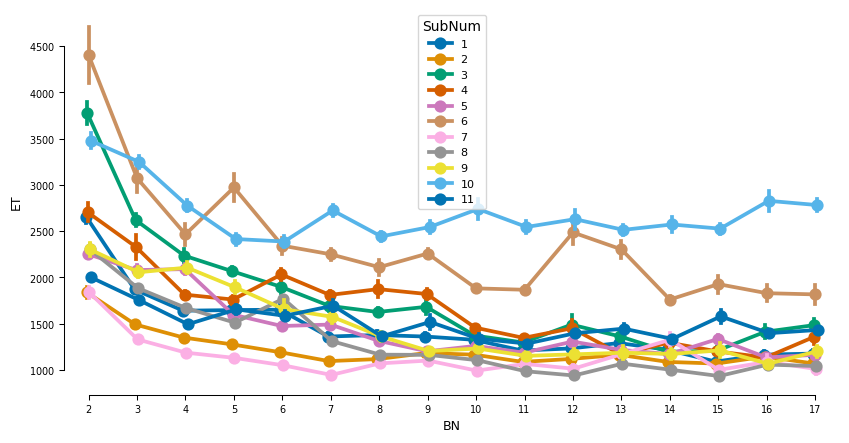

In [388]:
plt.figure(figsize=(10, 5))
sns.pointplot(data = subjs, x = 'BN', y = 'ET', errorbar = 'se', hue = 'SubNum', palette = 'colorblind', dodge = 0.1)
sns.despine(trim = True)

Subject 1: a=1407.96, b=0.5179, c=1176.74
Subject 2: a=673.16, b=0.5931, c=1063.47
Subject 3: a=2320.75, b=0.4483, c=1257.30
Subject 4: a=1338.31, b=0.1437, c=997.60
Subject 5: a=1161.29, b=0.3061, c=1118.81
Subject 6: a=1844.81, b=0.4842, c=1884.24
Subject 7: a=693.21, b=0.7346, c=963.60
Subject 8: a=1295.56, b=0.2223, c=866.04
Subject 9: a=1358.31, b=0.1821, c=883.81
Subject 10: a=1047.17, b=0.7828, c=2500.69
Subject 11: a=628.85, b=0.4624, c=1339.84


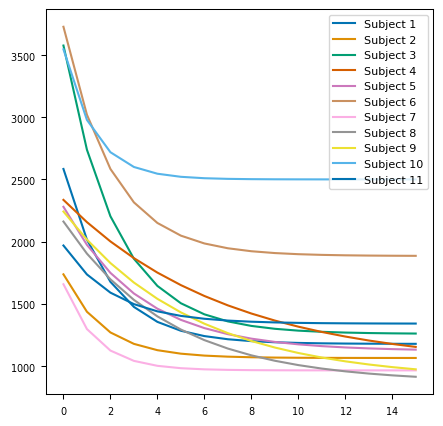

In [381]:
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

from scipy.optimize import curve_fit
fig = plt.figure(figsize=(5, 5))
for subind, subdata in grouped_ETs.groupby('SubNum'):
    xdata = subdata['BN'] - 2
    ydata = subdata['ET']
    popt, pcov = curve_fit(exp_func, xdata, ydata, bounds=(0, [5000., 1., 5000.]))
    print(f"Subject {subind}: a={popt[0]:.2f}, b={popt[1]:.4f}, c={popt[2]:.2f}")
    plt.plot(xdata, exp_func(xdata, *popt), label=f'Subject {subind}')

plt.legend()


